# 📘 S3_P4 — Spam : Naive Bayes, Régression logistique ET KNN

## 🎯 Ce que tu vas apprendre
1. (Reprise de S3_P2) Naive Bayes vs régression logistique sur le spam
2. Ajouter un 3e concurrent : **KNN** (k=4, puis 10)
3. Balayer k=1..19 avec 4 métriques et lire les 4 courbes
4. ⚠️ Découvrir un bug d'imports manquants (et pourquoi il ne se voit pas tout de suite !)

## 📖 Le dataset « Spambase »
4601 vrais emails, décrits par **57 caractéristiques numériques** calculées automatiquement : fréquence de certains mots (« free », « money », « credit »…), fréquence de caractères (« ! », « $ »), et longueur des suites de MAJUSCULES. La dernière colonne = le verdict : **1 = spam, 0 = email normal**. Les classes sont relativement équilibrées (~40 % spam / 60 % normal) — contrairement au MBA !

---
Imports numpy + pandas.

In [159]:
import numpy as np
import pandas as pd

## Étape 1 — Charger un fichier de données BRUT (pas un CSV classique)

**Ce que fait le code :** `np.loadtxt("spambase.data", delimiter=",")` — le fichier `.data` n'a **pas de ligne d'en-têtes** (pas de noms de colonnes), juste des nombres séparés par des virgules. `loadtxt` le lit en **tableau numpy** pur (pas un DataFrame).

**⚠️ Bizarrerie de code à remarquer :** `y = dataset = np.loadtxt(...)` est une **affectation chaînée** — `y` et `dataset` pointent vers le même tableau. Ça n'a aucun intérêt ici puisque `y` est immédiatement écrasé à la cellule suivante. Il suffisait d'écrire `dataset = np.loadtxt(...)`. (Pas un bug, juste du code inutilement confus.)

In [160]:
y = dataset = np.loadtxt("spambase.data",delimiter=",")

## Étape 2 — Extraire la cible : le slicing numpy

**Ce que fait le code :** `dataset[:, -1]` — décomposons cette syntaxe de **slicing** :
- avant la virgule : `:` = « toutes les lignes »,
- après la virgule : `-1` = « la dernière colonne » (les indices négatifs comptent depuis la fin).

→ `y` = la dernière colonne = les étiquettes spam/non-spam des 4601 emails.

In [161]:
y = dataset[:, -1]

**Vérification :** un tableau de 0.0 et 1.0, de forme (4601,). ✅

In [162]:
y

array([1., 1., 1., ..., 0., 0., 0.], shape=(4601,))

## Étape 3 — Extraire les features

`dataset[:, :-1]` : toutes les lignes, toutes les colonnes **SAUF la dernière** (`:-1` = du début jusqu'à l'avant-dernière incluse). On enveloppe dans `pd.DataFrame(...)` pour retrouver le confort de pandas.

In [163]:
X = pd.DataFrame(dataset[:,:-1])

**Aperçu de X :** 57 colonnes… nommées 0 à 56 (le fichier n'avait pas d'en-têtes). Dans la documentation officielle du dataset, ce sont : 48 fréquences de mots (`word_freq_make`, `word_freq_free`…), 6 fréquences de caractères (`char_freq_!`…), et 3 statistiques de MAJUSCULES (`capital_run_length_average/longest/total`). Un spam typique : beaucoup de « free », de « ! » et de MAJUSCULES.

In [164]:
X

,0,1,2,3,4,5,6,7,8,9,...,47,48,49,50,51,52,53,54,55,56
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.0,0.000,0.000,0.0,0.778,0.000,0.000,3.756,61.0,278.0
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.0,0.000,0.132,0.0,0.372,0.180,0.048,5.114,101.0,1028.0
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.0,0.010,0.143,0.0,0.276,0.184,0.010,9.821,485.0,2259.0
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.0,0.000,0.137,0.0,0.137,0.000,0.000,3.537,40.0,191.0
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.0,0.000,0.135,0.0,0.135,0.000,0.000,3.537,40.0,191.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4596,0.31,0.00,0.62,0.0,0.00,0.31,0.00,0.00,0.00,0.00,...,0.0,0.000,0.232,0.0,0.000,0.000,0.000,1.142,3.0,88.0
4597,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.0,0.000,0.000,0.0,0.353,0.000,0.000,1.555,4.0,14.0
4598,0.30,0.00,0.30,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.0,0.102,0.718,0.0,0.000,0.000,0.000,1.404,6.0,118.0
4599,0.96,0.00,0.00,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.0,0.000,0.057,0.0,0.000,0.000,0.000,1.147,5.0,78.0


Les imports de classification habituels (LogisticRegression, split, métriques) — cf. S2_P4 pour le détail.

In [165]:
from sklearn.linear_model import LogisticRegression 
from sklearn.model_selection import cross_val_predict,cross_val_score,train_test_split
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay


Split 80/20 : 3680 emails de train, 921 de test. `random_state=32`.

In [166]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2,random_state=32)

## Étape 4 — NOUVEL ALGORITHME : le Naive Bayes

**Import de `GaussianNB`** — troisième famille de modèles après la régression linéaire et logistique.

### 🧠 THÉORIE — Le Naive Bayes, expliqué pas à pas

**L'idée de départ — le théorème de Bayes :** on veut la probabilité qu'un email soit un spam SACHANT ses caractéristiques :

$$P(\text{spam} \mid \text{caractéristiques}) = \frac{P(\text{caractéristiques} \mid \text{spam}) \times P(\text{spam})}{P(\text{caractéristiques})}$$

**Décomposons chaque morceau :**
- $P(\text{spam})$ : la proportion de spams en général (~40 % ici) — le « prior », ce qu'on sait avant de lire l'email.
- $P(\text{caractéristiques} \mid \text{spam})$ : à quel point ces caractéristiques (beaucoup de « free », de « ! »…) sont typiques d'un spam.
- Le dénominateur normalise pour obtenir une probabilité propre.

**Le problème pratique :** estimer la probabilité JOINTE de 57 caractéristiques ensemble demanderait des quantités astronomiques de données.

**L'astuce « naïve » :** on SUPPOSE que les 57 caractéristiques sont **indépendantes entre elles** une fois la classe connue. La probabilité jointe devient alors un simple produit :

$$P(x_1, \dots, x_{57} \mid \text{spam}) \approx \prod_{i=1}^{57} P(x_i \mid \text{spam})$$

**Est-ce vrai ?** Non ! (« free » et « money » apparaissent souvent ENSEMBLE dans les spams — corrélés.) Mais cette approximation grossière marche étonnamment bien en pratique, et rend le calcul instantané.

**Et le « Gaussian » ?** `GaussianNB` suppose en plus que chaque caractéristique suit une **loi normale (en cloche)** dans chaque classe — c'est comme ça qu'il estime les $P(x_i \mid \text{classe})$.

In [167]:
from sklearn.naive_bayes import GaussianNB


**Entraîner + prédire en 3 lignes** — remarque que l'API est IDENTIQUE à la régression logistique (`fit`/`predict`) : c'est la grande force de sklearn, changer de modèle ne change pas le code autour.

In [168]:
NB = GaussianNB()
NB.fit(X_train,y_train)
y_pred = NB.predict(X_test)

## EVALUATE

## Étape 5 — Matrice de confusion du Naive Bayes

`confusion_matrix(y_test, y_pred)` — ✅ ordre correct, matrice fiable. Lignes = réalité (0 = normal, 1 = spam), colonnes = prédiction.

**🔍 Enjeu spécifique au spam — les deux erreurs ne se valent pas :**
- **FP** (email normal classé spam) : le mail important de ton patron part à la corbeille → TRÈS grave !
- **FN** (spam qui passe) : agaçant, mais bénin.
→ Pour un filtre anti-spam, on veut une **précision maximale** sur la classe spam, quitte à laisser passer quelques spams.

<Axes: >

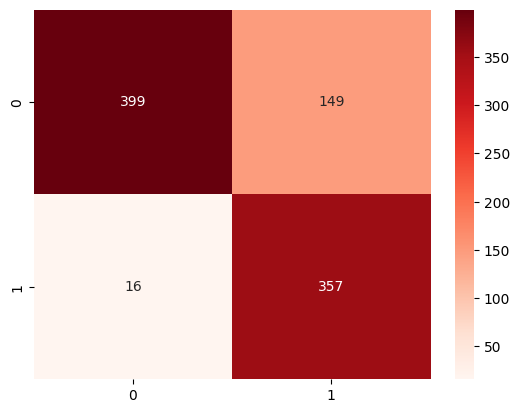

In [169]:
import seaborn as sns
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm, annot=True,cmap="Reds",fmt="d")

## 🔴 Étape 6 — Rapport de classification : arguments INVERSÉS (encore !)

`classification_report(y_pred, y_test)` — même erreur d'ordre qu'en S3_P1 : la réalité doit venir EN PREMIER. Conséquences (détail complet en S3_P1, étape 8) : les colonnes precision et recall sont **échangées**, et `support` compte les prédictions au lieu de la réalité.

**Ce qui reste lisible :** l'**accuracy = 0.82** (insensible à l'inversion). Sur un dataset presque équilibré comme celui-ci, l'accuracy est déjà un indicateur raisonnable (contrairement au MBA !) — mais corrige quand même l'ordre pour lire précision/rappel correctement.

In [170]:
print(classification_report(y_pred,y_test))


              precision    recall  f1-score   support

         0.0       0.73      0.96      0.83       415
         1.0       0.96      0.71      0.81       506

    accuracy                           0.82       921
   macro avg       0.84      0.83      0.82       921
weighted avg       0.85      0.82      0.82       921



## Étape 7 — Le concurrent : la régression logistique

**Ce que fait la cellule :** entraîne une LogisticRegression sur les MÊMES données, prédit, et affiche directement sa matrice de confusion — tout-en-un.

**⚠️ Le `ConvergenceWarning` (encore lui) :** les 57 features ont des échelles très différentes (fréquences ~0-1 vs longueurs de majuscules pouvant dépasser 1000). Sans standardisation (`StandardScaler`), l'optimiseur peine. Le modèle marche quand même, mais pourrait être meilleur.

**🔍 Compare les deux matrices de confusion (NB vs LR) :** regarde les cases hors diagonale — la régression logistique en a nettement moins.

c:\Users\kirit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


<Axes: >

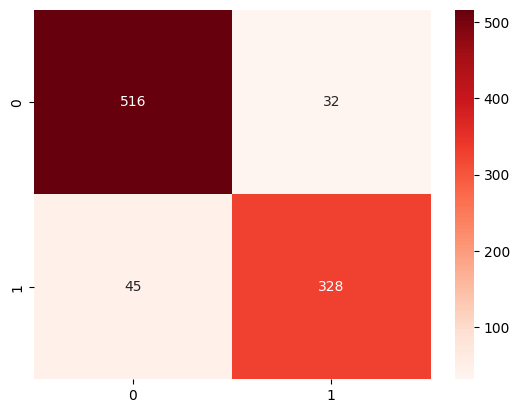

In [171]:
LR = LogisticRegression()
LR.fit(X_train,y_train)
y_pred = LR.predict(X_test)

cmLR = confusion_matrix(y_test,y_pred)
sns.heatmap(cmLR, annot=True,cmap="Reds",fmt="d")

## Étape 8 — Le verdict chiffré

Même inversion d'arguments (accuracy seule fiable) : **régression logistique 0.92 vs Naive Bayes 0.82**.

**Pourquoi la LR gagne ici ?** L'hypothèse « naïve » d'indépendance du NB est trop fausse sur ce dataset (les mots de spam sont très corrélés entre eux), alors que la LR apprend un poids par feature sans hypothèse d'indépendance. Le NB reste imbattable en rapidité et sur les petits jeux de données.

In [172]:
print(classification_report(y_pred,y_test))



              precision    recall  f1-score   support

         0.0       0.94      0.92      0.93       561
         1.0       0.88      0.91      0.89       360

    accuracy                           0.92       921
   macro avg       0.91      0.92      0.91       921
weighted avg       0.92      0.92      0.92       921



## try with K=4 , 10,20 check the CM & the classification report.


## Étape 9 — KNN entre en scène (k=4)

**Ce que fait la cellule :** import de `KNeighborsClassifier`, création avec `n_neighbors=4`, entraînement, prédiction, et matrice de confusion — tout-en-un. (Théorie KNN détaillée en S3_P3, étape 10 : distance euclidienne + vote majoritaire. Rappel du talon d'Achille : les échelles non standardisées — ici les longueurs de MAJUSCULES écrasent les fréquences de mots dans le calcul de distance !)

<Axes: >

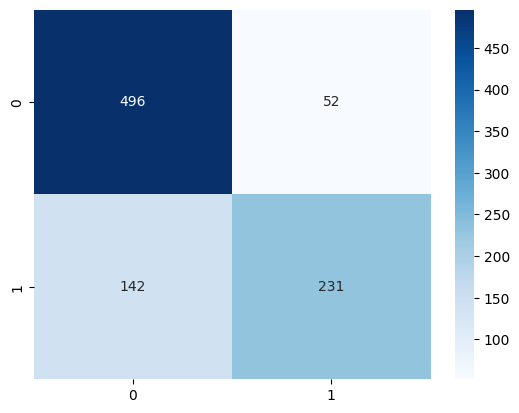

In [173]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import ConfusionMatrixDisplay
knn = KNeighborsClassifier(n_neighbors=4)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm, annot=True,cmap="Blues",fmt="d")

## ✅ Étape 10 — ENFIN le bon ordre !

`classification_report(y_test, y_pred)` — la réalité d'abord : **ce rapport se lit directement**, sans gymnastique mentale ! (Compare avec les cellules 6 et 8 du même notebook, encore inversées — l'auteur a corrigé son réflexe en cours de route 😉.)

**🔍 Lecture (k=4) :** accuracy **0.79** — en dessous de la LR (0.92) et même du NB (0.82). Précision spam 0.82 / rappel spam 0.62 : il rate 38 % des spams. Le KNN sans standardisation souffre sur ce dataset à 57 features d'échelles disparates.

In [174]:
print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

         0.0       0.78      0.91      0.84       548
         1.0       0.82      0.62      0.70       373

    accuracy                           0.79       921
   macro avg       0.80      0.76      0.77       921
weighted avg       0.79      0.79      0.78       921



Même expérience avec **k=10** — on augmente le nombre de voisins pour voir l'effet.

<Axes: >

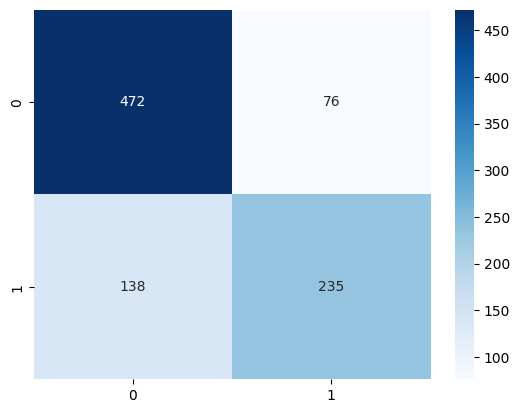

In [175]:
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm, annot=True,cmap="Blues",fmt="d")

**Rapport k=10 (ordre correct ✅) :** accuracy **0.77** — encore PIRE que k=4 ! Augmenter k a lissé davantage la frontière, sans régler le vrai problème (les échelles). Le classement reste : LR (0.92) > NB (0.82) > KNN (0.77-0.79).

In [176]:
print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

         0.0       0.77      0.86      0.82       548
         1.0       0.76      0.63      0.69       373

    accuracy                           0.77       921
   macro avg       0.76      0.75      0.75       921
weighted avg       0.77      0.77      0.76       921



⚠️ **Cellule dupliquée** : c'est un copier-coller EXACT de la cellule k=10 précédente — même modèle, mêmes données, aucune nouveauté. (Le markdown au-dessus annonçait « try with K=4, 10, 20 » : le k=20 a probablement été oublié, remplacé par ce doublon.)

<Axes: >

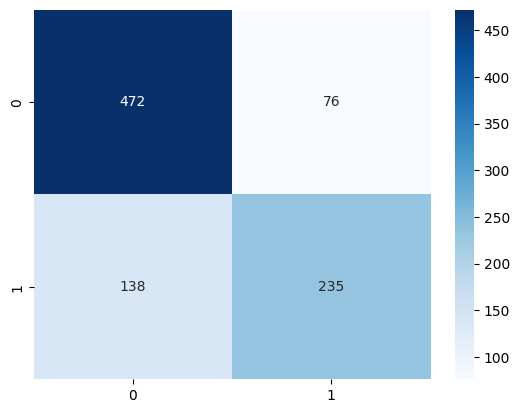

In [177]:
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm, annot=True,cmap="Blues",fmt="d")

Rapport identique à celui de la cellule 19 (rien n'a changé entre les deux exécutions).

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       0.77      0.86      0.82       548
         1.0       0.76      0.63      0.69       373

    accuracy                           0.77       921
   macro avg       0.76      0.75      0.75       921
weighted avg       0.77      0.77      0.76       921



## 🔴 Étape 11 — La boucle des métriques… avec un bug INVISIBLE

**Ce que fait le code :** même boucle qu'en S3_P3 (k=1..19, 4 métriques par k).

**LE BUG :** `accuracy_score`, `precision_score`, `recall_score`, `f1_score` ne sont **importés NULLE PART dans ce notebook** ! (Compare avec S3_P3 qui a bien sa cellule d'import.)

**Pourquoi ça marche quand même à l'écran ?** Piège Jupyter classique : le **noyau (kernel) garde en mémoire** tout ce qui a été exécuté depuis son démarrage — y compris des imports faits dans une cellule **supprimée depuis**, ou dans un autre état antérieur du notebook. Les fonctions « existent » en mémoire… mais pas dans le fichier !

**La preuve :** fais *Kernel → Restart & Run All* → `NameError: name 'accuracy_score' is not defined` à cette cellule.

**La correction :** ajouter `from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score`.

**⭐ Leçon fondamentale sur les notebooks :** un notebook qui « marche » ne prouve rien — seul un notebook qui marche APRÈS un redémarrage complet du noyau est réellement correct. Prends l'habitude du Restart & Run All avant de rendre un travail. *(Code non modifié — note documentaire.)*

In [ ]:

accuracy = []
precision = []
f1 = []
recall = []
list_k = []
for k in range(1,20,1):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    list_k.append(k)
    accuracy.append(accuracy_score(y_test,y_pred))
    precision.append(precision_score(y_test, y_pred))
    recall.append(recall_score(y_test,y_pred))
    f1.append(f1_score(y_test, y_pred))

## 📊 Étape 12 — Les 4 courbes d'un coup (et comment les lire)

**Ce que fait le code :** construit le DataFrame des résultats puis enchaîne 4 `plot` → 4 graphiques (Accuracy, Précision, F1, Rappel vs k).

**🔍 Lecture d'ensemble (dataset presque équilibré, contrairement au MBA !) :**
- Les 4 courbes se comportent de façon **cohérente** entre elles (pas le grand écart accuracy/rappel du MBA).
- Cherche le k où le **F1 culmine** — souvent un petit k ici (3-7), car le dataset est grand et les frontières spam/normal assez nettes.
- Toutes les courbes **déclinent doucement** quand k grandit : le lissage excessif dilue l'information locale.

## 📝 Résumé du notebook
1. Classement final sur le spam : **LR (0.92) > NB (0.82) > KNN (0.77-0.79)** — le KNN souffre des échelles non standardisées.
2. Augmenter k n'aide pas toujours (0.79 → 0.77) : le compromis biais-variance n'est pas magique.
3. 🔴 **Le piège du kernel Jupyter** : des fonctions peuvent « exister » en mémoire sans être importées dans le fichier — Restart & Run All est le seul juge de paix.
4. ✅ Progrès dans le code : les derniers `classification_report` sont dans le bon ordre !

<Axes: xlabel='K'>

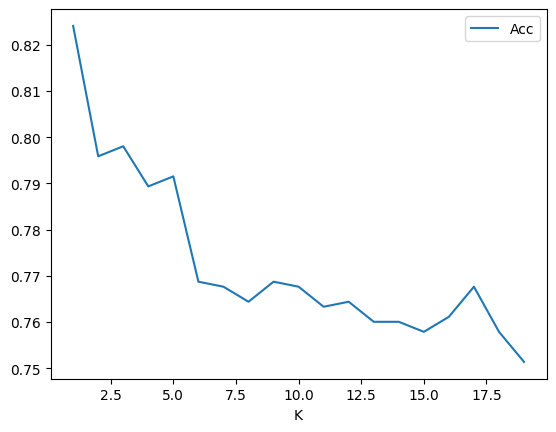

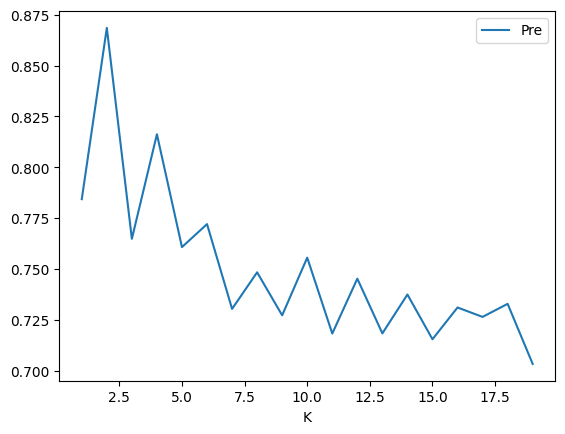

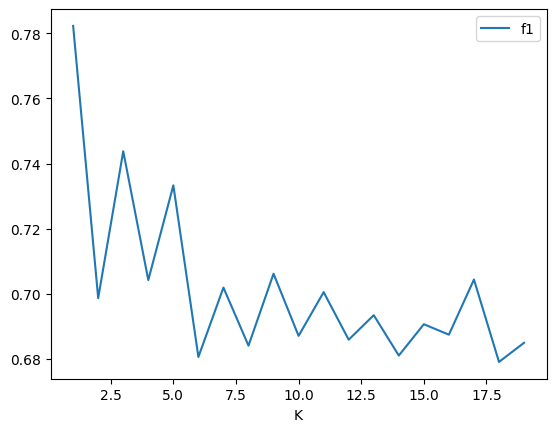

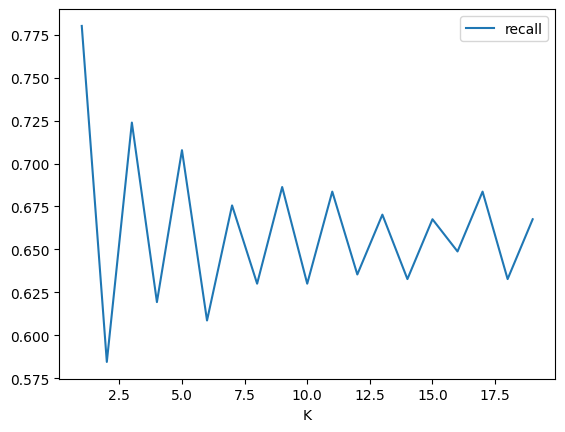

In [180]:
metrics_df = pd.DataFrame({"K":list_k,"Acc":accuracy,"Pre":precision,"f1":f1,"recall":recall})
metrics_df.plot(x = "K",y = "Acc")
metrics_df.plot(x = "K",y = "Pre")
metrics_df.plot(x = "K",y = "f1")
metrics_df.plot(x = "K",y = "recall")